In [1]:
from roboflow import Roboflow
rf = Roboflow(api_key="PGOOPri6K18wauX4SmkL")
project = rf.workspace("dataforvisiondetectercars").project("car-damage-zone-detector")
version = project.version(6)
dataset = version.download("coco")


loading Roboflow workspace...
loading Roboflow project...


In [2]:
import torch

# Зачищаємо кеш пам'яті на всякий випадок
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Перевіряємо пристрій
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Модель буде навчатися на: {device}")

Модель буде навчатися на: cuda


In [3]:
import torch
from rfdetr import RFDETRMedium

# 2. Ініціалізуємо модель RF-DETR (Medium)
model = RFDETRMedium()

model.train(
    dataset_dir=r"data/Car-Damage-Zone-Detector-6",  # Шлях до розпакованого датасету
    epochs=100,                                   # Кількість епох для хорошого результату
    batch_size=8,                                # Якщо виникне помилка пам'яті (OOM), зменшіть до 2
    device=device
)

target=True is deprecated since `v0.8`; use `TargetMode.ARGS_REMAP` instead. Will be removed in `v1.0`.


[2026-06-25 01:30:29] [INFO] rf-detr - File C:\Users\Roman Shypka\.roboflow\models\rf-detr-medium.pth already exists with correct MD5 hash.


[2026-06-25 01:30:29] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-25 01:30:29] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-06-25 01:30:30] [INFO] rf-detr - File C:\Users\Roman Shypka\.roboflow\models\rf-detr-medium.pth already exists with correct MD5 hash.


[2026-06-25 01:30:32] [WARNING] rf-detr - Pretrained weights at 'C:\\Users\\Roman Shypka\\.roboflow\\models\\rf-detr-medium.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.
[2026-06-25 01:30:34] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-25 01:30:34] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


...

Trainable params: 33.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.4 M                                                                                               
Total estimated model params size (MB): 133.498                                                                    
Modules in train mode: 483                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[2026-06-25 01:31:54] [INFO] rf-detr - Best EMA mAP improved to 0.0017 (epoch 0)
[2026-06-25 01:36:22] [INFO] rf-detr - Best regular checkpoint saved to C:\Users\Roman Shypka\Smoloskyp\autoria\auctions\output\checkpoint_best_regular.pth (epoch 0, monitor=val/mAP_50_95, value=0.030374)
[2026-06-25 01:36:23] [INFO] rf-detr - Best EMA mAP improved to 0.0309 (epoch 0)
[2026-06-25 01:41:08] [INFO] rf-detr - Best regular checkpoint saved to C:\Users\Roman Shypka\Smoloskyp\autoria\auctions\output\checkpoint_best_regular.pth (epoch 1, monitor=val/mAP_50_95, value=0.0917601)
[2026-06-25 01:41:08] [INFO] rf-detr - Best EMA mAP improved to 0.0914 (epoch 1)
[2026-06-25 01:45:41] [INFO] rf-detr - Best regular checkpoint saved to C:\Users\Roman Shypka\Smoloskyp\autoria\auctions\output\checkpoint_best_regular.pth (epoch 2, monitor=val/mAP_50_95, value=0.133273)
[2026-06-25 01:45:41] [INFO] rf-detr - Best EMA mAP improved to 0.1237 (epoch 2)
[2026-06-25 01:49:27] [INFO] rf-detr - Best regular checkpoi

`Trainer.fit` stopped: `max_epochs=100` reached.


[2026-06-25 08:48:02] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.1987, ema=0.1998)


In [90]:
import os
import glob
import cv2
from ultralytics import RTDETR

# 1. Вказуємо ПРАВИЛЬНИЙ шлях до файлу твоєї моделі (.pt)
# Візьмемо фінальний чекпоінт, який зберігся у тебе на 12-й епосі
model_path = r"C:\Users\Roman Shypka\Smoloskyp\autoria\auctions\output\detect_damage_zone_final.pt"
model = RTDETR(model_path)

# 2. Шлях до папки з картинками, які ТИ ХОЧЕШ ПЕРЕВІРИТИ (тестові фото)
# Наприклад, твій шлях до папки з битими авто:
image_folder = r"C:\Users\Roman Shypka\Smoloskyp\autoria\auctions\data\front_damage"

# Шукаємо всі .jpg файли в цій папці
test_images = glob.glob(os.path.join(image_folder, "*.jpg"))

print(f"Знайдено {len(test_images)} зображень для тесту.")

# 3. Запускаємо перевірку для перших 5 фотографій, щоб оцінити результат
for img_path in test_images[:5]:
    print(f"Обробка: {os.path.basename(img_path)}")
    
    # conf=0.25 — покаже бокси, де модель впевнена хоча б на 25%
    # save=True — автоматично збереже результат з накресленими боксами
    results = model.predict(source=img_path, conf=0.25, save=True, project="local_tests")

TypeError: ERROR  C:\Users\Roman Shypka\Smoloskyp\autoria\auctions\output\detect_damage_zone_final.pt references types outside the supported Ultralytics checkpoint format. Use an official Ultralytics model, i.e. 'yolo predict model=yolo26n.pt'

In [86]:
import sys
!{sys.executable} -m pip install ultralytics

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 9.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/836.9 kB ? eta -:--:--
   --------------------------------------- 836.9/836.9 kB 13.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/52.7 MB ? eta -:--:--
    --------------------------------------- 1.0/52.7 MB 7.2 MB/s eta 0:00:08
   -- ------------------------------------- 3.4/52.7 MB 9.2 MB/s eta 0:00:06
   ---- ----------------------------------- 5.8/52.7 MB 10.2 MB/s eta 0:00:05
   ------ --------------------------------- 8.1/52.7 MB 10.5 MB/s eta 0:00:05
   ------- -------------------------------- 9.4/52.7 MB 9.7 MB/s eta 0:00:05
   ------- -------------------------------- 10.0/52.7 MB 8.9 MB/s eta 0:00:05
   -------- ------------------------------- 10.7/52.7 MB 7.7 MB/s eta 0:00:06
   -------- -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


[2026-06-26 14:00:47] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-26 14:00:47] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-26 14:00:47] [WARNING] rf-detr - Checkpoint has 3 classes but model is configured for 90. Using checkpoint class count (3). Pass num_classes=3 to suppress this warning.
[2026-06-26 14:00:47] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.
[2026-06-26 14:00:48] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


=================== РЕЗУЛЬТАТИ НОВОЇ МОДЕЛІ ===================
🎯 Знайдено пошкоджень: 1
🆔 ID класів: [2]
📊 Впевненість (conf): [0.9159145]


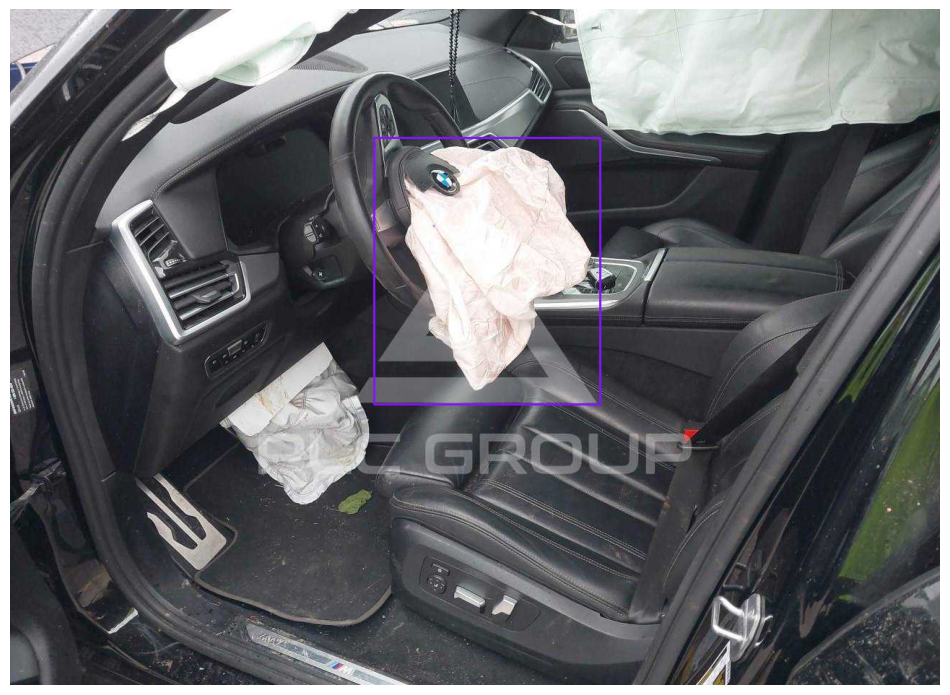

In [5]:
import os
import numpy as np
import supervision as sv
from PIL import Image
from rfdetr import RFDETRMedium

# 1. Вкажи шлях до НОВОГО файлу ваг, який створився після model.train()
# ПЕРЕВІР, куди саме скрипт зберіг результати (наприклад, "output/checkpoint_best_regular.pth")
NEW_MODEL_PATH = "output/detect_damage_zone_final.pth" 

# 2. Ініціалізуємо нову модель (додаємо patch_size=16, якщо датасет знову з Roboflow)
new_model = RFDETRMedium(pretrain_weights=NEW_MODEL_PATH, patch_size=16)

# 3. Шлях до фотографії, яку хочеш перевірити (можна з водяними знаками Auto.RIA)
image_path = r"C:\Users\Roman Shypka\Smoloskyp\autoria\data\model_2\damaged_bumper\5790525692620508884.jpg"

# 4. Чисте читання через PIL
pil_img = Image.open(image_path)

# 5. Робимо передбачення новою моделькою
results = new_model.predict(images=pil_img, conf=0.25) # знизив поріг до 0.10 для тесту
detections = results[0]

print("=================== РЕЗУЛЬТАТИ НОВОЇ МОДЕЛІ ===================")
print(f"🎯 Знайдено пошкоджень: {len(detections)}")
print(f"🆔 ID класів: {detections.class_id}")
print(f"📊 Впевненість (conf): {detections.confidence}")

# 6. Малюємо рамки, якщо модель щось знайшла
if len(detections) > 0:
    box_annotator = sv.BoxAnnotator(color=sv.ColorPalette.ROBOFLOW)
    annotated_image = pil_img.copy()
    annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
    
    # Виводимо зображення прямо в Jupyter Notebook
    sv.plot_image(annotated_image)
else:
    print("❌ Нова модель не знайшла дефектів на цьому фото при conf=0.25")

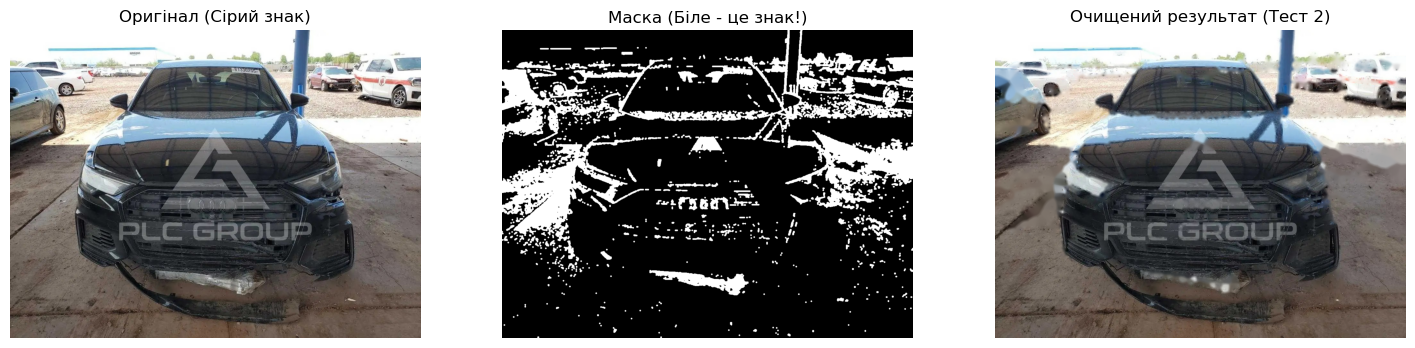

In [104]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- НАЛАШТУВАННЯ ДЛЯ PLC GROUP ---
# Шлях до вашої чорної Ауді
image_path = r"C:\Users\Roman Shypka\Smoloskyp\autoria\data\model_2\damaged_bumper\5844834750919544466.jpg"

def remove_gray_watermark_for_plc(img_path):
    # 1. Завантажуємо зображення
    img = cv2.imread(img_path)
    if img is None:
        print("❌ Помилка: не знайдено файл!")
        return None
        
    # Створюємо RGB копію для відображення
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 2. Переводимо в сірий колір
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 3. Створюємо маску (НАЙВАЖЛИВІШИЙ КРОК)
    # Замість простого thresholds ми використовуємо діапазон, 
    # щоб зловити напівпрозорий сірий колір PLC літер.
    # Значення [130, 160] зазвичай ідеально ловлять ці літери на чорному капоті.
    mask = cv2.inRange(gray, 130, 160)
    
    # 4. Покращуємо маску (прибираємо шум)
    # Трохи розширимо лінії літер, щоб зафарбувати надійніше
    kernel = np.ones((5,5), np.uint8) # збільшив ядро до 5x5
    mask = cv2.dilate(mask, kernel, iterations=1)
    
    # Можна ще трішки розмити, щоб згладити краї
    mask = cv2.medianBlur(mask, 3)
    
    # 5. ЗАМАЛЬОВУЄМО (Inpainting)
    # Збільшуємо радіус до 10, щоб він сильніше змішував сусідні пікселі
    cleaned = cv2.inpaint(img_rgb, mask, inpaintRadius=10, flags=cv2.INPAINT_TELEA)
    
    return cleaned, mask, img_rgb

# --- ЗАПУСК ТА ВІДОБРАЖЕННЯ ---
cleaned_image, mask, original_rgb = remove_gray_watermark_for_plc(image_path)

if cleaned_image is not None:
    # Виводимо результати для перевірки
    plt.figure(figsize=(18, 10))
    
    # Попередній перегляд оригіналу
    plt.subplot(1, 3, 1)
    plt.title("Оригінал (Сірий знак)")
    plt.imshow(original_rgb)
    plt.axis('off')
    
    # Показуємо маску (саме вона була порожньою у вас)
    plt.subplot(1, 3, 2)
    plt.title("Маска (Біле - це знак!)")
    # Тепер тут мають бути видно білі контури PLC GROUP
    plt.imshow(mask, cmap='gray') 
    plt.axis('off')
    
    # Фінальний результат
    plt.subplot(1, 3, 3)
    plt.title("Очищений результат (Тест 2)")
    plt.imshow(cleaned_image)
    plt.axis('off')
    
    plt.show()

In [16]:
# 1. Витягуємо взагалі всі приховані та публічні атрибути моделі
all_attributes = dir(model)

print("==================================================")
print("🔍 ЗНАЙДЕНІ КЛАСИ ТА СЛОВНИКИ ВСЕРЕДИНІ МОДЕЛИ:")
print("==================================================")

# Шукаємо будь-які змінні, де фігурують слова 'class' або 'name'
found_any = False
for attr in all_attributes:
    if 'class' in attr.lower() or 'name' in attr.lower():
        try:
            value = getattr(model, attr)
            # Якщо це список або словник — виводимо його вміст
            if isinstance(value, (list, dict, tuple)) and len(value) > 0:
                print(f"📌 Змінна: model.{attr}")
                print(f"   Вміст: {value}\n")
                found_any = True
        except:
            continue

# Якщо класи заховані всередині підмоделі (.model)
if hasattr(model, 'model'):
    for attr in dir(model.model):
        if 'class' in attr.lower() or 'name' in attr.lower():
            try:
                value = getattr(model.model, attr)
                if isinstance(value, (list, dict, tuple)) and len(value) > 0:
                    print(f"📌 Змінна: model.model.{attr}")
                    print(f"   Вміст: {value}\n")
                    found_any = True
            except:
                continue

if not found_any:
    print("❌ Прямих списків в атрибутах першого рівня не знайдено.")
    print("Спробуй вивести сирий словник конфігу:")
    if hasattr(model, 'cfg'): print(model.cfg)

print("==================================================")

🔍 ЗНАЙДЕНІ КЛАСИ ТА СЛОВНИКИ ВСЕРЕДИНІ МОДЕЛИ:
📌 Змінна: model.class_names
   Вміст: ['Auto-Auction-Damage-MVP', 'Circles_marks', 'X-marks', 'broken_glass', 'broken_headlight', 'broken_mirror', 'damage_front_bamber', 'damaged-hood', 'damaged_rear_bumper', 'damaged_trunk', 'damaged_upholstery', 'damaged_wheel', 'dent', 'deployed_airbag_front', 'deployed_airbag_rear', 'door_damage', 'flooded_interior', 'ground', 'interior_corrosion', 'messy_interier', 'missing_bumper', 'missing_rear_bumper', 'rust', 'scratch', 'severe_bumper_damage', 'severe_door_damage', 'severe_rear_bumper_damage', 'severe_side_damage', 'side_damage']

📌 Змінна: model.model.class_names
   Вміст: ['Auto-Auction-Damage-MVP', 'Circles_marks', 'X-marks', 'broken_glass', 'broken_headlight', 'broken_mirror', 'damage_front_bamber', 'damaged-hood', 'damaged_rear_bumper', 'damaged_trunk', 'damaged_upholstery', 'damaged_wheel', 'dent', 'deployed_airbag_front', 'deployed_airbag_rear', 'door_damage', 'flooded_interior', 'ground', 

In [13]:
from PIL import Image
import cv2

# 1. Шлях до фото, де модель точно бачила дефекти (наприклад, твоя Audi чи Toyota)
test_img_path = r"C:\Users\Roman Shypka\Smoloskyp\autoria\data\model_2\damaged_bumper\5844834750919544466.jpg"

# 2. Завантажуємо картинку
pil_img = Image.open(test_img_path).convert("RGB")

# 3. Робимо інференс
results = model.predict(images=pil_img, conf=0.20)
detections = results[0]

print("==================================================")
if len(detections) > 0:
    print("🎯 СИРІ ДАНІ З РЕЗУЛЬТАТУ ДЕТЕКЦІЇ:")
    print("Цифрові ID (class_id):", detections.class_id)
    
    # Витягуємо назви класів, якщо supervision їх підтягнув
    if detections.data and 'class_name' in detections.data:
        print("Текстові імена (class_name):", detections.data['class_name'])
        
        print("\n🔥 ТОЧНИЙ ЗБІГ:")
        for cid, name in zip(detections.class_id, detections.data['class_name']):
            print(f"Індекс {cid} ————> це клас '{name}'")
    else:
        print("Supervision не підтягнув текстові назви.")
        print("Тоді просто подивимось на унікальні ID, які знайшла модель:", set(detections.class_id))
else:
    print("❌ Модель не знайшла дефектів на цьому фото при conf=0.20. Спробуй інше фото.")
print("==================================================")

❌ Модель не знайшла дефектів на цьому фото при conf=0.20. Спробуй інше фото.
